In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import os
print(os.getcwd())

C:\Users\Fernando\changerisk


In [10]:
df = pd.read_csv(
    "data/raw/pandas_pulls_pilot_100_enriched.csv"
)

df.head()

,pr_number,title,author,created_at,updated_at,closed_at,merged_at,merge_commit_sha,commits,changed_files,additions,deletions,code_churn,comments,review_comments,labels,sample_year
0,50498,DOC: Add `pip install odfpy` for io.rst,luke396,2022-12-30T04:09:56Z,2022-12-31T02:13:03Z,2022-12-30T15:06:35Z,2022-12-30T15:06:35Z,42b0b7acde4fb34c813d5430dd396dc9fc8a3620,3,1,1,1,2,1,3,"['Docs', 'IO Excel']",2022
1,50488,TST: GH50347 create test for groupby sum of bo...,Daquisu,2022-12-29T19:39:55Z,2022-12-30T15:07:24Z,2022-12-30T15:07:18Z,2022-12-30T15:07:18Z,d859ecc1b0e386a66a5e0650609a9e3154fa474c,3,1,10,0,10,1,4,['Groupby'],2022
2,50485,CI/WEB: Adding cache for maintainers' github info,datapythonista,2022-12-29T08:20:29Z,2023-01-04T10:33:52Z,2022-12-29T10:29:28Z,2022-12-29T10:29:28Z,2899f46f87a1dc254f331e6d6d5138a2a195703a,1,2,23,0,23,4,0,"['CI', 'Web']",2022
3,50484,DOC: Clean dubious docstring,luke396,2022-12-29T08:13:27Z,2022-12-30T03:41:47Z,2022-12-29T15:29:08Z,2022-12-29T15:29:08Z,0720b035a8eb947ea442debd2579f2431a2e869e,5,1,15,16,31,4,3,"['Docs', 'Clean']",2022
4,50469,CLN: avoid NpyDatetimeUnit in tests,jbrockmendel,2022-12-28T15:33:09Z,2022-12-28T19:07:49Z,2022-12-28T17:50:56Z,2022-12-28T17:50:56Z,e423eeea8b28a44d5153c6307a56f374fe69ea88,1,3,7,31,38,1,0,"['Testing', 'Non-Nano']",2022


In [11]:
df.shape

(100, 17)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   pr_number         100 non-null    int64
 1   title             100 non-null    str  
 2   author            100 non-null    str  
 3   created_at        100 non-null    str  
 4   updated_at        100 non-null    str  
 5   closed_at         100 non-null    str  
 6   merged_at         100 non-null    str  
 7   merge_commit_sha  100 non-null    str  
 8   commits           100 non-null    int64
 9   changed_files     100 non-null    int64
 10  additions         100 non-null    int64
 11  deletions         100 non-null    int64
 12  code_churn        100 non-null    int64
 13  comments          100 non-null    int64
 14  review_comments   100 non-null    int64
 15  labels            100 non-null    str  
 16  sample_year       100 non-null    int64
dtypes: int64(9), str(8)
memory usage: 13.4 KB


In [13]:
df.isna().sum()

pr_number           0
title               0
author              0
created_at          0
updated_at          0
closed_at           0
merged_at           0
merge_commit_sha    0
commits             0
changed_files       0
additions           0
deletions           0
code_churn          0
comments            0
review_comments     0
labels              0
sample_year         0
dtype: int64

In [14]:
df.duplicated(subset="pr_number").sum()

np.int64(0)

In [15]:
numeric_cols = [
    "commits",
    "changed_files",
    "additions",
    "deletions",
    "code_churn",
    "comments",
    "review_comments"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
commits,100.0,2.31,2.604173,1.0,1.00,1.0,3.00,15.0
changed_files,100.0,3.94,5.602705,1.0,1.00,2.0,4.00,34.0
additions,100.0,43.08,110.215370,0.0,4.00,15.0,38.00,1016.0
deletions,100.0,30.51,88.276825,0.0,1.00,6.0,24.25,683.0
code_churn,100.0,73.59,184.475839,1.0,10.75,22.5,66.00,1539.0
comments,100.0,1.07,0.977060,0.0,1.00,1.0,1.00,5.0
review_comments,100.0,0.92,2.657864,0.0,0.00,0.0,0.00,22.0


In [16]:
df[
    [
        "pr_number",
        "title",
        "sample_year",
        "changed_files",
        "additions",
        "deletions",
        "code_churn",
    ]
].sort_values(
    "code_churn",
    ascending=False
).head(10)

,pr_number,title,sample_year,changed_files,additions,deletions,code_churn
95,63457,DOC: Inline docstrings in strings/accessor.py ...,2025,1,1016,523,1539
71,60566,DEPR: Enforce deprecation of include_groups in...,2024,24,271,683,954
86,63487,TST:Replacing all ensure_cleans with pytest fi...,2025,31,125,160,285
14,50441,REF: share TimedeltaArray division code,2022,3,101,134,235
39,56656,Backport PR #56650 on branch 2.2.x (ENH: Imple...,2023,4,231,1,232
42,56650,ENH: Implement dt methods for pyarrow duration...,2023,4,231,1,232
18,50435,BUG: inconsistent handling of exact=False cas...,2022,6,170,44,214
7,50455,DEPR: Enforce alignment with numpy ufuncs,2022,4,51,139,190
94,63464,DOC: replace @doc with docstrings in pandas.fa...,2025,2,136,49,185
97,63451,PERF: Pass copy=False to Index constructor,2025,34,94,78,172


In [17]:
df["created_at"] = pd.to_datetime(
    df["created_at"],
    utc=True
)

df["merged_at"] = pd.to_datetime(
    df["merged_at"],
    utc=True
)

df["pr_duration_hours"] = (
    df["merged_at"] - df["created_at"]
).dt.total_seconds() / 3600

df["pr_duration_hours"].describe()

count    100.000000
mean      26.104636
std       39.241112
min        0.298611
25%        2.197431
50%        9.946111
75%       27.794861
max      202.469722
Name: pr_duration_hours, dtype: float64

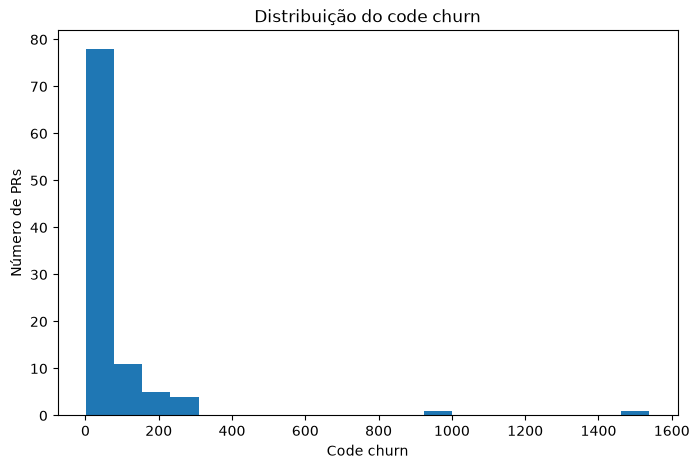

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["code_churn"],
    bins=20
)

plt.xlabel("Code churn")
plt.ylabel("Número de PRs")
plt.title("Distribuição do code churn")

plt.show()

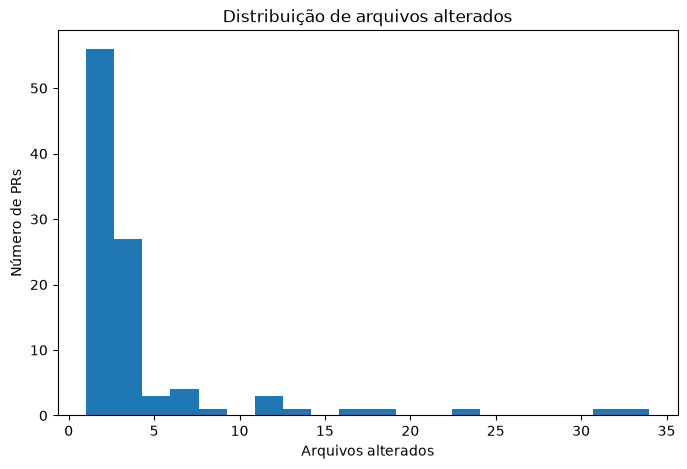

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["changed_files"],
    bins=20
)

plt.xlabel("Arquivos alterados")
plt.ylabel("Número de PRs")
plt.title("Distribuição de arquivos alterados")

plt.show()

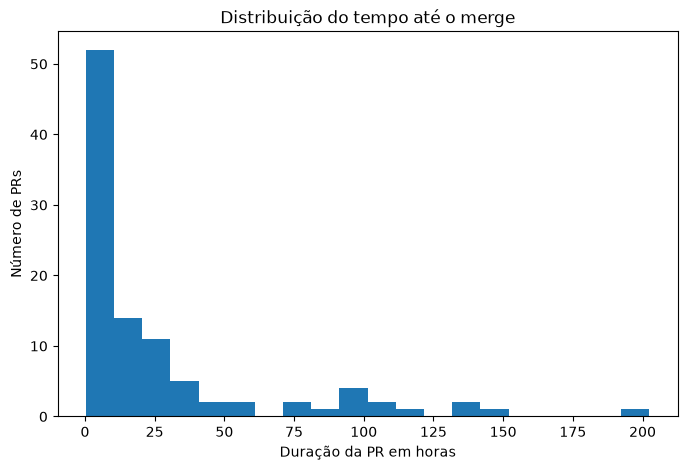

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["pr_duration_hours"],
    bins=20
)

plt.xlabel("Duração da PR em horas")
plt.ylabel("Número de PRs")
plt.title("Distribuição do tempo até o merge")

plt.show()